## **Charging the Gaps: Evaluating Electric Vehicle Charging Deserts Along U.S. Interstates - Mapping Coverage, Gaps, and Mobility Demand**
##### GEOG573 Final Project, Professor: Dr. Song Gao
##### Drew Barkman, May Liu, Sam Leibowitz
---




## **Part I: Introduction**
Electric vehicles (EVs) are reshaping long‑distance travel in the United States, yet the charging network that supports them remains uneven and often difficult to navigate. For extended travel, effective route planning is essential to avoid delays, requiring attention to the spatial distribution of charging stations as well as charger compatibility and charging speed. According to Varga et al. (2019), driving range continues to be the primary factor influencing consumers’ decisions to adopt electric vehicles, making it essential to assess whether the existing charging infrastructure actually enables drivers to use that range effectively on long‑distance routes. This project evaluates how well EV drivers can road‑trip across the country by mapping charging station coverage along interstate highways, identifying where chargers are reliably spaced, where major gaps exist, and how these gaps align with real travel demand.

We integrate two national datasets: **EV charging station data** and **highway mobility‑flow data**. EV stations are overlaid with the nearest interstate nodes to assess road‑trip‑relevant accessibility. ```(Calvo‑Jurado et al., 2024)``` A 5‑mile buffer along the interstate system and a 25-mile buffer around each station are applied to isolate “EV charging deserts,” defined as highway segments where no Level 2 or DC Fast chargers are reachable within a reasonable detour. These deserts are then intersected with traffic metrics such as AADT (Annual Average Daily Traffic) to determine which gaps matter most for real‑world travel. 

We proposes potential optimal sites for expanding the electric vehicle charging network, grounded in the spatial distribution of existing infrastructure. The resulting insights are valuable for firms seeking to identify strategic investment locations. The final deliverable is a list of high‑priority charging gaps along U.S. interstates, supported by national and corridor‑level maps created in matplotlib and pydeck. By revealing where heavy travel demand meets limited charging access, this project highlights the most critical barriers to seamless electric road‑tripping.



## **Part II: Method**
- write about the methods we will be using
- first, Sam did preliminary analysis & visualization through ArcGIS 
- then, we did...

## **Part II: Data Processing & Preliminary Analysis**

### **Data Background & Selection**

We will cross analyze two open source datasets:
1. **EV Charging Stations database**: 
The U.S. Department of Energy’s Alternative Fuels Data Center (AFDC) provides the national database of public EV charging stations. Each record includes station location, access type, charging level, connector type, and operational status. For this project, we filter stations to reflect non‑commercial, long‑distance personal travel.

    Filters applied:
    - ```Region - United States```
    - ```Car Class Type - Class 1 & Class 2```: These two classes reflect light-duty vehicles. Class 1 includes passenger cars, minivans, SUVs, and small pickup trucks, while Class 2 includes standard-size pickup trucks and camper vans.
    - ```Charger Type - Level 2 & DC Fast```: Level 2 adds 15–40 miles per hour and is common for commutes, and DC Fast Chargers provide 100-300+ miles in 30–60 minutes, best for road trips. Level 1 is mainly for overnight at-home charging; we will thus focus on Level 2 and DC Fast chargers.
    - ```Connector Type - CCS (DC), J1772 (AC), NACS(J3400 AC/DC)```: 
        - **CCS (Combined Charging System)**: the most common DC connector for non‑Tesla EVs, used by most non‑Tesla EVs sold before 2025 for DC Fast charging. 
        - **J1772**: the universal AC connector for non‑Tesla EVs, used by all non‑Tesla EVs for Level 2 charging. This represents the majority of workplace, apartment, and public slow‑charging infrastructure. 
        - **NACS (North American Charging Standard)**: the new dominant standard, now adopted by nearly every major automaker for North America starting 2025–2026. Backed by Tesla’s Supercharger network, which is the largest and most reliable fast‑charging network in the U.S.

2. **National Highway Traffic Mobility‑flow data**:
The U.S. Department of Transportation's public data portal provides data on national mobility‑flow, including attributes such as roadway geometry and traffic demand metrics for U.S. highways. Key attributes include route identifiers, begin/end points, segment length, functional classification, and traffic volumes such as AADT (Annual Average Daily Traffic) and truck AADT. These fields capture how heavily each segment is used and allow us to weight EV charging gaps by real travel demand. This dataset is essential for distinguishing minor gaps from those that meaningfully affect long‑distance mobility. To reflect non-commercial roadtrip car types, we will be using ```AADT``` to quantify mobility flow.

### **Data Download & Cleaning**
- Current EV Charger Location Data
- Highway Mobility Flow Data 

In [1]:
pip install dask-geopandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import geopandas as gpd
import dask_geopandas as dgpd
import matplotlib.pyplot as plt

In [3]:
USA_48_STATES_BBOX = (-128.320313,24.367114,-65.039063,50.401515)

In [4]:
# load charger location 
us_chargers = pd.read_csv('data/USChargingLocations.csv')
us_chargers = gpd.GeoDataFrame(us_chargers, geometry = gpd.points_from_xy(us_chargers['Longitude'], us_chargers['Latitude']))
us_chargers = us_chargers.cx[USA_48_STATES_BBOX[0]:USA_48_STATES_BBOX[2], USA_48_STATES_BBOX[1]:USA_48_STATES_BBOX[3]]

C:\Users\May\AppData\Local\Temp\ipykernel_23452\4183308285.py:2: DtypeWarning: Columns (20,40,64,69) have mixed types. Specify dtype option on import or set low_memory=False.
  us_chargers = pd.read_csv('data/USChargingLocations.csv')


In [5]:
# load interstate data
# big file, took at least 3 mins to load
interstates = gpd.read_file('data/spatial_interstates_w_mobility.geojson', bbox = USA_48_STATES_BBOX)
interstates.shape

(875213, 99)

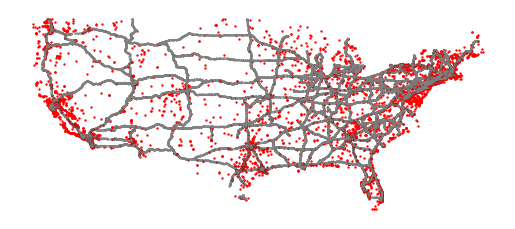

In [6]:
# plot both together
ax = interstates.plot(color='grey')
us_chargers.plot(ax = ax, color='red', markersize=0.5)
ax.set_axis_off()

In [7]:
us_chargers = us_chargers.set_crs('EPSG:4326')
us_chargers.crs == interstates.crs

True

### **Preliminary Analysis & Visualization**
In this section, we build a national‑scale EV charging accessibility map by identify chargers near interstates, setting 5-mile buffer off each side of the interstate, then visualizing the charger's 25‑mile radius service area. 25-mile was chosen Then, we overlay traffic volumes to reveal charging deserts along major U.S. corridors, shown by a color-grade where darker color (ie. purple, black...) indicates higher traffic flows and lighter color (ie. yellow, orange...) indicates lower traffic flows.



In [8]:
# Buffering the interstate network by 1 mile to find chargers near interstates
interstates_1_mile = interstates.to_crs('EPSG:9311').buffer(1609.344)   # 1609.344 m = 1 mi
# merged_interstates_buffer = interstates_1_mile.union_all()

In [9]:
# Spatially joining chargers to those buffers to keep only chargers within 1 mile of an interstate
chargers_by_interstate = gpd.sjoin(
    us_chargers.to_crs('EPSG:9311'), 
    gpd.GeoDataFrame(geometry=interstates_1_mile), 
    how="inner", 
    predicate="intersects"
).drop_duplicates(subset='ID')

In [12]:
# simplifying the interstate geometries for faster plotting
interstates_simple = interstates.to_crs('EPSG:9311')
interstates_simple['geometry'] = interstates_simple.simplify(500)
interstates_simple = interstates_simple[interstates_simple.is_valid & ~interstates_simple.is_empty]

In [13]:
print(interstates_simple.total_bounds)

[-1952079.01431408 -2111246.854987    2399583.82264467   681288.33806999]


Interstate Bounds: [-1952079.01431408 -2111246.854987    2399583.82264467   681288.33806999]
Buffer Bounds: [-1991114.77669242 -2123178.28299194  2435499.134888     719872.73064662]


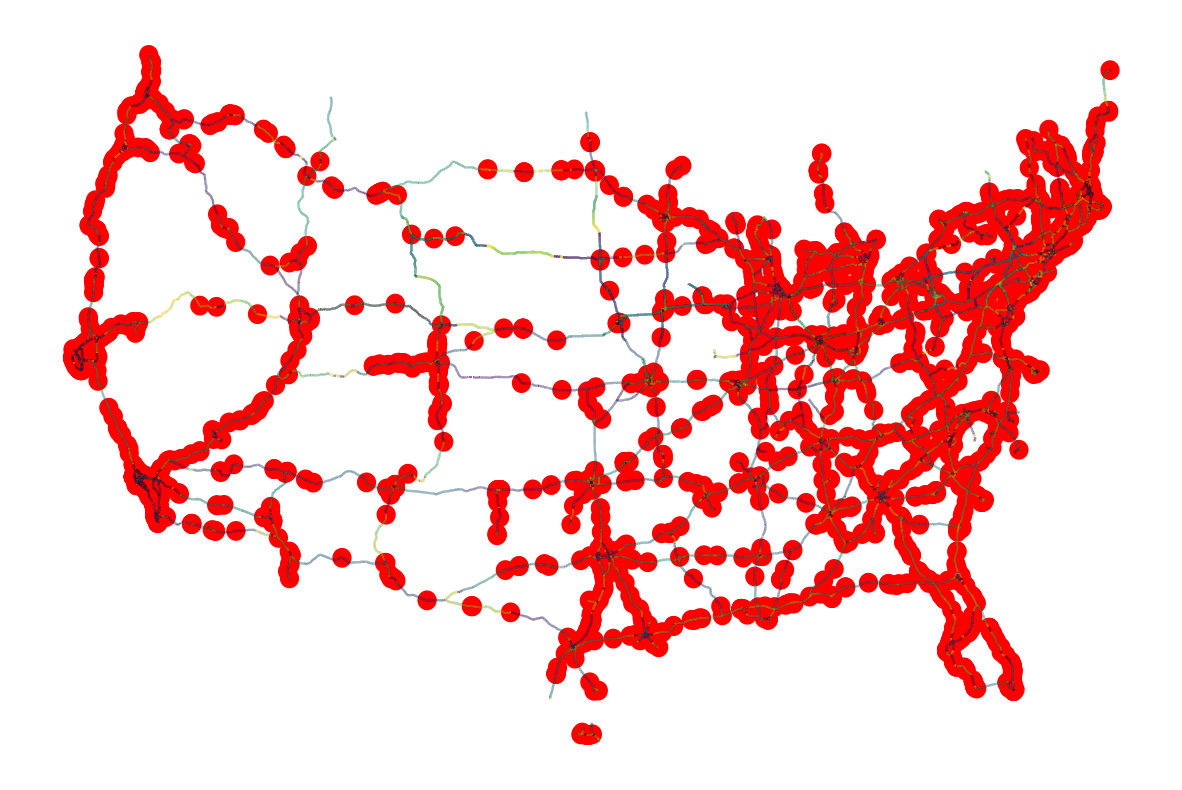

In [14]:
fig, ax = plt.subplots(figsize=(15, 10))

# Buffering chargers by 25 miles to visualize coverage zones
charger_buffers = chargers_by_interstate.to_crs('EPSG:9311')
charger_buffers = charger_buffers.buffer(1609.344 * 25)   # 1609.344 m = 1 mi

charger_buffers = charger_buffers[charger_buffers.is_valid & ~charger_buffers.is_empty]

print("Interstate Bounds:", interstates_simple.total_bounds)
print("Buffer Bounds:", charger_buffers.total_bounds)

# Plotting the simplified interstates + charger coverage buffers 
# Interstates colored by AADT (traffic volume)
interstates_simple.plot(ax = ax,
                        alpha = 0.5, 
                        column='aadt', 
                        cmap='viridis',
                        legend=False)
# Charger coverage zones in red
charger_buffers.plot(ax = ax, color='red', markersize=0.5)

#ax.set_xlim(-2500000, 2500000)
#ax.set_ylim(-1500000, 1500000)
ax.set_xlim(None)  # changed drew's boundaries
ax.set_ylim(None) # changed drew's boundaries

ax.set_aspect('auto')

ax.set_axis_off()

In [15]:
interstates.columns

Index(['aadt', 'aadt_combination', 'aadt_d', 'aadt_single_unit',
       'access_control', 'at_grade_other', 'base_thickness', 'base_type',
       'begin_point', 'counter_peak_lanes', 'county_id', 'cracking_percent',
       'cracking_percent_d', 'curves_a', 'curves_b', 'curves_c', 'curves_d',
       'curves_e', 'curves_f', 'dir_factor', 'dir_through_lanes', 'end_point',
       'facility_type', 'faulting', 'faulting_d', 'future_aadt_year',
       'f_system', 'future_aadt', 'grades_a', 'grades_b', 'grades_c',
       'grades_d', 'grades_e', 'grades_f', 'iri', 'iri_d', 'is_restricted',
       'k_factor', 'lane_width', 'last_overlay_thickness',
       'maintenance_operations', 'managed_lanes', 'managed_lanes_type',
       'median_type', 'median_width', 'nhfn', 'nhs', 'nn', 'number_signals',
       'ownership', 'pct_dh_combination', 'pct_dh_single_unit',
       'pct_green_time', 'pct_pass_sight', 'peak_lanes', 'peak_parking', 'psr',
       'psr_d', 'route_id', 'route_number', 'route_qualifier

-AADT is null in a lot of rows since it is measured one way - delete all the null ones 

## **Part III: Analysis & Visualization**

We define interstate segments located beyond the 25‑mile service buffer as ***charging deserts***. After isolating these desert segments, we sorted them using a customized priority index designed to identify locations with the most urgent need for additional charging infrastructure. The index is calculated as ```VMT×(distance to nearest EV station)```, which highlights segments that combine high travel demand with poor charger accessibility. Possible location of new stations is presented, situated at a minimum distance of 25 miles from competing/existing stations and no more than 5 miles from interstates. To avoid redundancy, we consolidated overlapping segments within the same municipality or region and generated a *top‑ten ranking* of priority areas.



In [17]:
# 1. Convert interstates into a routable edge table; each row = one interstate segment
# Explode multi-line geometries into individual lines
edges = interstates_simple.explode(index_parts=False).reset_index(drop=True)
# Add a unique ID for each segment
edges['edge_id'] = edges.index

edges[['aadt']].head()

,aadt
0,None
1,None
2,None
3,None
4,None


In [22]:
# 2. Compute charger service areas using network distance 
charger_buffers = chargers_by_interstate.to_crs('EPSG:9311').buffer(1609.344 * 25)
charger_buffers = gpd.GeoDataFrame(geometry=charger_buffers, crs='EPSG:9311')

# determine which interstate segments intersect at least one charger buffer
# Now each segment has: covered = True → within 25 miles of a charger, covered = False → EV charging desert
covered = gpd.sjoin(
    edges,
    charger_buffers,
    how='left',
    predicate='intersects'
)

covered_edges = covered[~covered.index_right.isna()].index.unique()
edges['covered'] = edges.index.isin(covered_edges)

In [23]:
# extract actual desert section
desert_segments = edges[edges['covered'] == False].copy()

In [24]:
# 3. Merge AADT onto segments
desert_segments = desert_segments.merge(
    interstates_simple[['aadt', 'geometry']],
    left_on='edge_id',
    right_index=True,
    how='left'
)

In [28]:
# 4. compute gap length (clean first)
if "geometry_x" in desert_segments.columns:
    desert_segments = desert_segments.set_geometry("geometry_x")
    desert_segments = desert_segments.rename(columns={"geometry_x": "geometry"})

if "geometry_y" in desert_segments.columns:
    desert_segments = desert_segments.drop(columns=["geometry_y"])

desert_segments = desert_segments.set_geometry("geometry", inplace=False)

desert_segments['length_miles'] = desert_segments.length / 1609.344

In [29]:
# 5. Group contiguous desert segments into “gaps”
desert_segments = desert_segments.sort_values('edge_id')
desert_segments['gap_id'] = (desert_segments['edge_id'].diff() != 1).cumsum()

In [34]:
# clean
if "aadt_x" in desert_segments.columns:
    desert_segments = desert_segments.rename(columns={"aadt_x": "aadt"})

if "aadt_y" in desert_segments.columns:
    desert_segments = desert_segments.drop(columns=["aadt_y"])

In [36]:
# 6. rank gaps by priority (priority score combines AADT (higher = more important) + Gap length (longer = more severe))
gap_stats = (
    desert_segments
    .groupby('gap_id')
    .agg(
        total_length_miles=('length_miles', 'sum'),
        mean_aadt=('aadt', 'mean'),
        max_aadt=('aadt', 'max'),
        segment_count=('edge_id', 'count')
    )
)

# Priority score: length × traffic
gap_stats['priority_score'] = gap_stats['total_length_miles'] * gap_stats['mean_aadt']

gap_stats = gap_stats.sort_values('priority_score', ascending=False)

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
gap_stats.head(20)

In [ ]:
# 7. map the desert segments
fig, ax = plt.subplots(figsize=(15, 10))

interstates_simple.plot(ax=ax, color='lightgray', linewidth=0.5)
desert_segments.plot(ax=ax, color='red', linewidth=2)

ax.set_axis_off()

network analysis

Because EV charging isn’t just about distance—it’s about connectivity.

A charger 50 miles away is useless if:

it requires a huge detour

it’s off a low‑importance spur

it doesn’t serve the main flow of traffic

it doesn’t cover a structurally critical corridor

Network analysis lets you identify:

the most important gaps

the most painful detours

the most central missing chargers

the most fragile parts of the system
## we will do:
1. by usage: 
- flow-weighted metric (AADT)
2. by structural importance:
- betweenness
    - find structurally important gaps
    - Compare betweenness vs charger presence.
    - High betweenness + desert = nationally important gap.
    - High betweenness + low AADT = “quiet but structurally essential” corridor.
- closeness
    - High closeness + desert = central but under‑served corridor.
    - Low closeness + desert = remote areas (expected deserts).
- other options: redundancy/alternative routes, detour burden
3. final: flow-weighted betweenness
- betweenness*AADT
- this is top‑priority national EV gap.

## **Part IV: Results**

centrality metrics 
1. edge betweenness on interstate
- For each “desert segment,” aggregate betweenness (mean/max) of its edges.
- High‑betweenness deserts = gaps on nationally important through‑routes
- further: Multiply edge betweenness by AADT to get a flow‑weighted criticality score for each gap

2. closeness 
- Compute node closeness on the interstate graph
- How close a node is, on average, to all other nodes in the network—global accessibility
- Gaps in high‑closeness regions indicate missing chargers in already well‑connected parts of the system (where EV travel “should” be easy but isn’t).

In [ ]:
# Future Implications & Proposal
# map of where we want to propose new EV charging locations
# rapid city & SD??

## **Part V: Conclusion**
- paragraph of brief summary of results and proposal.
- discussion of research gaps/future suggestions?

## **Part VI: Acknowledgement, References, & Contribution**
### **References**
- U.S. Department of Energy, Alternative Fuels Data Center. (2026). Electric Vehicle Charging Station Locations [Data set]. Retrieved April 12, 2026, from https://afdc.energy.gov/fuels/electricity-locations
- U.S. Census Bureau. (2023). TIGER/Line Shapefile: U.S. Primary Roads [Data set]. Retrieved April 12, 2026, from https://catalog.data.gov/dataset/tiger-line-shapefile-2023-nation-u-s-primary-roads
- Calvo‑Jurado, C., Ceballos‑Martínez, J. M., García‑Merino, J. C., Muñoz‑Solano, M., & Sánchez‑Herrera, F. J. (2024). Optimal location of electric vehicle charging stations using proximity diagrams. Sustainable Cities and Society, 113, 105719. https://doi.org/10.1016/j.scs.2024.105719
- Varga B.O., Sagoian A., Mariasiu F. (2019). Prediction of electric vehicle range: A comprehensive review of current issues and challenges Energies, 12 (5), p. 946, https://doi.org/10.3390/en12050946



### **Contribution Table**
| Contribution | Member |
|--------|-------------|
| Conceptualization   | All |
| Proposal Writeup    | May |
| Data Processing: Code | Drew & Sam |
| Data Processing: Writeup | May |
| Preliminary Analysis & Visualization (In ArcGIS)| Sam |
| Modelling & Analysis  | Drew & Sam |
| Visualization  | Drew & Sam |
| Final Report Writeup| May |
| Presentation Slides | May & Sam |
| Final Presentation  | All |